This notebook provides examples to go along with the [textbook](http://manipulation.csail.mit.edu/pick.html).  I recommend having both windows open, side-by-side!

In [3]:
import pydot
from IPython.display import SVG, display
from pydrake.all import MultibodyPlant, Parser

from manipulation.utils import ConfigureParser

# Inspecting the kinematic tree

Here is a simple example that demonstrates how to inspect the kinematic tree stored in a `MultibodyPlant`.

INFO:drake:PackageMap: Downloading https://github.com/RobotLocomotion/models/archive/68e906556069eab9896f9006b6bf17a32b8b0f1d.tar.gz


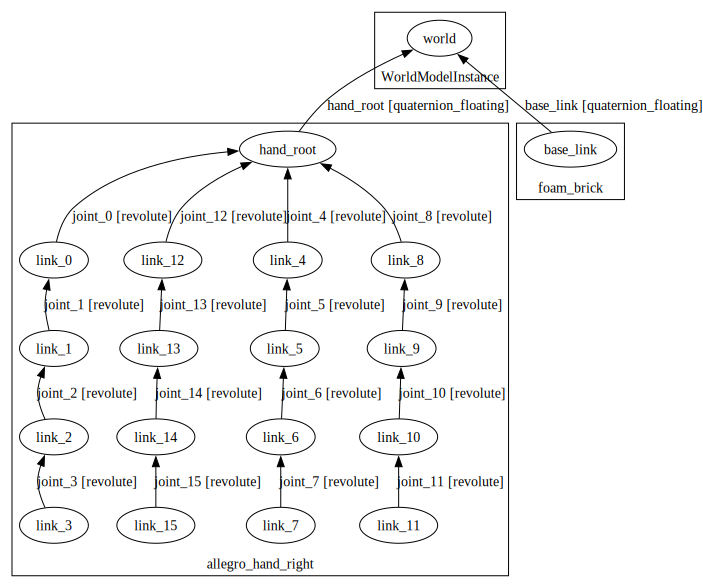

In [4]:
def kinematic_tree_example():
    plant = MultibodyPlant(time_step=0.0)
    parser = Parser(plant)
    ConfigureParser(parser)
    parser.AddModelsFromUrl(
        "package://drake_models/allegro_hand_description/sdf/allegro_hand_description_right.sdf"
    )
    parser.AddModelsFromUrl(
        "package://drake_models/manipulation_station/061_foam_brick.sdf"
    )
    plant.Finalize()

    # TODO(russt): Add floating base connections
    # TODO(russt): Consider a more interactive javascript rendering?
    display(
        SVG(
            pydot.graph_from_dot_data(plant.GetTopologyGraphvizString())[0].create_svg() # type: ignore
        )
    )


kinematic_tree_example()